# <center> Time Serie Visualizer </center>

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

from matplotlib.widgets import Button
import ipywidgets as widgets
import matplotlib
import matplotlib.pyplot as plt
 
from mpl_interactions import ipyplot as iplt
from mpl_interactions import hyperslicer
import ipywidgets as widgets

from dataloader_CIRCA.viz.ts_vis import TimeSerieVisualizer
from dataloader_CIRCA.datasets import CircaPatchDataSet

# %matplotlib ipympl

In [3]:
store_dai = Path("/home/SPeillet/Partage/store-dai")

path_dataset_CIRCA = store_dai / "projets/pac/3str/EXP_2"
data_optique = path_dataset_CIRCA / "Data_Raster" / "optique_dataset"
data_radar = path_dataset_CIRCA / "Data_Raster" / "radar_dataset_v4"
patch_size = 256

ds = CircaPatchDataSet(
    data_optique=data_optique,
    data_radar=data_radar,
    patch_size=256,
    no_filter=True,
#     load_dataset="./datasetCIRCAUnCRtainTS.csv",
)

mgrs:   0%|          | 0/35 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/2 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/4 [00:00<?, ?it/s]

...

mgrs25:   0%|          | 0/1 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/1 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

In [4]:
sample = next(iter(ds))

AttributeError: 'Controls' object has no attribute 'vbox'

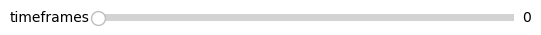

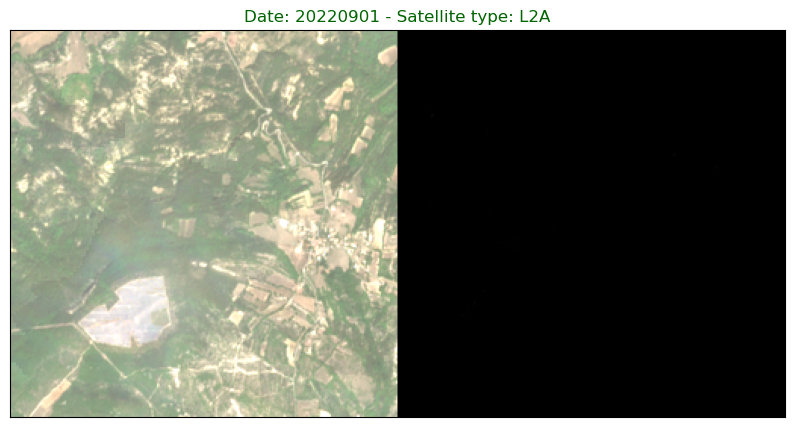

In [5]:
ui = TimeSerieVisualizer(
    data={
        "img": sample["data_S2"],
        "msk": sample["masks"],
    },
    dates=sample["dates_S2"].tolist(),
    sat_types="L2A",
)()

In [10]:
from dataloader_CIRCA.datasets.UTILISE_flash import UTILISE_Flash 

In [16]:
store_dai = Path("/home/SPeillet/Partage/store-dai")
path_dataset_circa = store_dai / "projets/pac/3str/EXP_2"
data_optique = path_dataset_circa / "Data_Raster" / "optique_dataset"
data_radar = path_dataset_circa / "Data_Raster" / "radar_dataset_v4"
patch_size = 256
overlap = 0

mask_kwargs = {
    "mask_type": "random_clouds",             # Strategy for synthetic data gap generation. ['random_clouds', 'real_clouds']
    "ratio_masked_frames": 0.5,               # Ratio of partially/fully masked images in a satellite image time series (upper bound).
    "ratio_fully_masked_frames": 0.0,         # Ratio of fully masked images in a satellite image time series (upper bound).
    "fixed_masking_ratio": True,              # False de base, True to vary the masking ratio across satellite image time series, False otherwise.
    "non_masked_frames": [0],                 # list of int, time steps to be excluded from masking.
    "intersect_real_cloud_masks": False,      # True to intersect randomly sampled cloud masks with the actual cloud mask sequence, False otherwise.
    "dilate_cloud_masks": False,              # True to dilate the cloud masks before masking, False otherwise.
    "fill_type": "fill_value",                # Strategy for initializing masked pixels. ['fill_value', 'white_noise', 'mean']
    "fill_value": 1,                          # Pixel value of masked pixels. Used if fill_type == 'fill_value'.
}

ds = UTILISE_Flash(
    data_optique=data_optique,
    data_radar=data_radar,
    hdf5_file=(store_dai / "tmp/speillet/debug_circa.hdf5"),
    load_dataset="datasetCIRCAUnCRtainTS.csv",
    patch_size=patch_size,
    overlap=overlap,
    shuffle=False,
    use_SAR=True,
    mask_kwargs=mask_kwargs,
    # channels="all",
    # return_cloud_prob=False,
    # render_occluded_above_p=None,
    # augment=False,
    # seq_length=30,
    # pe_strategy='day-of-year',
)

# ds.setup()
# ds.export_dataset()
sample = next(iter(ds))
print(sample.keys())

dict_keys(['x', 'y', 'masks', 'masks_valid_obs', 'position_days', 'days', 'sample_index', 'filepath', 'c_index_rgb', 'c_index_nir', 'S2_dates', 'cloud_prob', 'cloud_mask', 'S1_dates'])


In [13]:
sample["x"].shape

torch.Size([77, 14, 256, 256])

In [14]:
sample["y"].shape

torch.Size([77, 10, 256, 256])

In [15]:
ds.num_channels

15

In [17]:
ds.c_index_rgb

tensor([3, 2, 1])

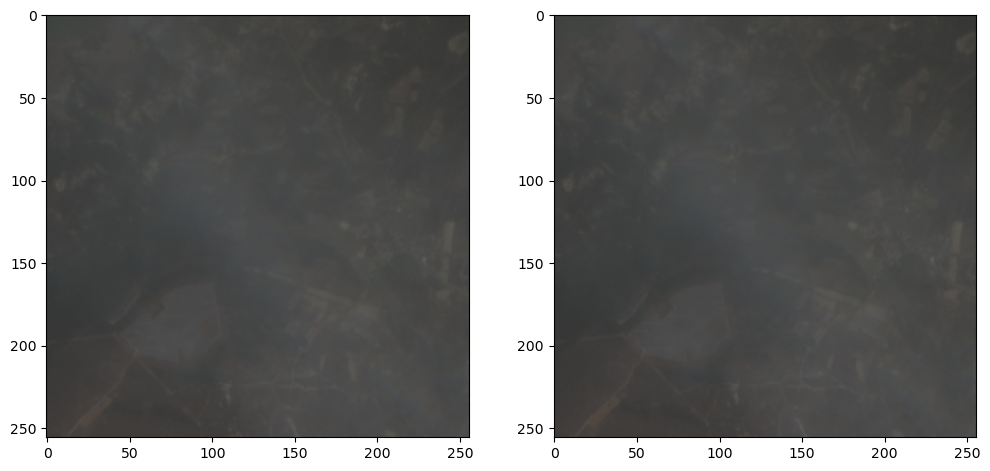

In [39]:
import matplotlib.pyplot as plt

t = 42
index_rgb = [2, 1, 0]

def to_display(array, t, index_rgb=[2,1,0]):
    data = array[t, index_rgb, :, :]
    # data = np.clip( / 2500, 0, 1)
    return data.numpy().transpose((1, 2, 0))

pred = to_display(sample["x"], t)
gt = to_display(sample["y"], t)

plt.figure(figsize=(12, 12))
plt.subplot(121)
plt.imshow(pred)
plt.subplot(122)
plt.imshow(gt)
plt.show()

In [5]:
import rasterio

f = "/home/SPeillet/Partage/store-dai/projets/pac/3str/EXP_2/Data_Raster/optique_dataset/31TGK/MGRS25-31TGK_row-4_col-2/bands_stacked_31TGK_row-4_col-2.tif"

In [92]:
rasterio.__version__

'1.3.8'

In [94]:
import gdal
gdal

ModuleNotFoundError: No module named 'gdal'

In [59]:
f = "/home/SPeillet/pac_rpg/bands_stacked_31TGK_row-4_col-2.tif"

In [48]:
from rasterio.windows import Window
f = "/home/SPeillet/Partage/store-dai/projets/pac/3str/EXP_2/Data_Raster/optique_dataset/31TGK/MGRS25-31TGK_row-4_col-2/bands_stacked_31TGK_row-4_col-2.tif"
with rasterio.open(f, "r+") as src:
    profile = src.profile
    array = src.read(564, window=Window(0, 0, 2048, 2049))
    #array = src.read(564, window=Window(0, 0, 100, 100))
    # print(array.shape)

RasterioIOError: Read failed. See previous exception for details.

In [30]:
profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 2196, 'height': 2196, 'count': 936, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 721919.5130334749,
       0.0, -10.0, 4934160.2552345665), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'interleave': 'band'}

In [52]:
from osgeo import gdal

# Ouvrir le fichier TIFF
dataset = gdal.Open(f)

if dataset is None:
    print("Impossible d'ouvrir le fichier TIFF.")
else:
    print("Fichier TIFF ouvert avec succès !")
    
    # Extraire des informations
    print(f"Nombre de bandes : {dataset.RasterCount}")
    print(f"Taille de l'image : {dataset.RasterXSize} x {dataset.RasterYSize}")
    
    # Lire une bande (par exemple, la première bande)
    
    band = dataset.GetRasterBand()
    array = band.ReadAsArray()
    print("Tableau NumPy de la bande :", array)

    # Fermer le dataset (important pour libérer la mémoire)
    dataset = None

Fichier TIFF ouvert avec succès !
Nombre de bandes : 936
Taille de l'image : 2196 x 2196


TypeError: Dataset_GetRasterBand expected 2 arguments, got 1

In [58]:
from rasterio.windows import Window
from rasterio import Env
with Env(GDAL_ERROR_ON_CORRUPT_BLOCK='NO'):
    f = "/home/SPeillet/Partage/store-dai/projets/pac/3str/EXP_2/Data_Raster/optique_dataset/31TGK/MGRS25-31TGK_row-4_col-2/bands_stacked_31TGK_row-4_col-2.tif"
    with rasterio.open(f, "r+") as src:
        profile = src.profile
        array = src.read(565, window=Window(0, 0, 2048, 2048))
        #array = src.read(564, window=Window(0, 0, 100, 100))
        # print(array.shape)

In [59]:
np.unique(array)

array([ 7616,  7624,  7636,  7640,  7644,  7652,  7656,  7660,  7664,
        7668,  7676,  7680,  7684,  7688,  7696,  7700,  7704,  7708,
        7712,  7720,  7724,  7728,  7732,  7740,  7744,  7748,  7752,
        7756,  7764,  7768,  7772,  7776,  7784,  7788,  7792,  7796,
        7800,  7808,  7812,  7816,  7820,  7828,  7832,  7836,  7840,
        7844,  7852,  7856,  7860,  7864,  7872,  7876,  7880,  7884,
        7888,  7896,  7900,  7904,  7908,  7916,  7920,  7924,  7928,
        7932,  7940,  7944,  7948,  7952,  7960,  7964,  7968,  7972,
        7976,  7984,  7988,  7992,  7996,  8000,  8008,  8012,  8016,
        8020,  8028,  8032,  8036,  8040,  8044,  8052,  8056,  8060,
        8064,  8072,  8076,  8080,  8084,  8088,  8096,  8100,  8104,
        8108,  8116,  8120,  8124,  8128,  8132,  8140,  8144,  8148,
        8152,  8160,  8164,  8168,  8172,  8176,  8184,  8188,  8192,
        8200,  8208,  8216,  8224,  8232,  8240,  8248,  8256,  8264,
        8272,  8280,

In [ ]:
4__629__519__360

In [56]:
2196 * 2196 * 12 * 80 

4629519360

In [ ]:
# gdal c++ debugger doc gdal 

In [ ]:
# regarde quel type de bande cest? 

In [57]:
564 % 12

0